# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

## 1. Carga de Datos

In [1]:
# SETUP Y CARGA DE DATOS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.impute import KNNImputer


# Configuración visual para gráficos profesionales
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
# Evitar notación científica en pandas para mejor legibilidad
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Carga de datos ESTRICTAMENTE desde el set de entrenamiento
# Ajusta la ruta relativa según dónde esté tu notebook (usualmente una carpeta arriba)
try:
    housing = pd.read_csv('../data/interim/train_set.csv')
    print(f"Dataset de entrenamiento cargado: {housing.shape[0]} filas y {housing.shape[1]} columnas.")
except FileNotFoundError:
    print("Error: No se encontró el archivo. Verifica la ruta relativa.")

# Creamos una copia de trabajo para no alterar el dataframe original en memoria
df_eda = housing.copy()

# AUDITORÍA DE CALIDAD DE DATOS (DATA QUALITY)
def quality_report(df):
    """
    Genera un reporte exhaustivo de calidad de datos.
    Evalúa completitud, tipos de datos, cardinalidad y sensibilidad (distribución).
    """
    report = pd.DataFrame({
        'Tipo de Dato': df.dtypes,
        'Nulos (Completitud)': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / len(df)) * 100,
        'Valores Únicos': df.nunique(),
        # La asimetría (skew) indica si la cola va a la derecha (>0) o izquierda (<0)
        'Asimetría (Skewness)': df.skew(numeric_only=True),
        # La curtosis indica qué tan pesadas son las colas (presencia extrema de outliers)
        'Curtosis (Kurtosis)': df.kurtosis(numeric_only=True)
    })
    
    # Ordenar por porcentaje de nulos descendente
    return report.sort_values(by='% Nulos', ascending=False).round(2)

# Ejecutar el reporte
quality_df = quality_report(df_eda)
display(quality_df)
display(df_eda.describe())
display(df_eda)

Dataset de entrenamiento cargado: 16512 filas y 10 columnas.


,Tipo de Dato,Nulos (Completitud),% Nulos,Valores Únicos,Asimetría (Skewness),Curtosis (Kurtosis)
total_bedrooms,float64,168,1.020,1827,3.440,21.350
households,float64,0,0.000,1712,3.360,20.900
housing_median_age,float64,0,0.000,52,0.060,-0.800
latitude,float64,0,0.000,835,0.450,-1.140
median_house_value,float64,0,0.000,3674,0.990,0.350
longitude,float64,0,0.000,817,-0.290,-1.340
median_income,float64,0,0.000,10930,1.620,4.780
ocean_proximity,str,0,0.000,5,NaN,NaN
population,float64,0,0.000,3640,3.280,20.240
total_rooms,float64,0,0.000,5473,4.160,33.210


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000,16512.000,16512.000,16512.000,16344.000,16512.000,16512.000,16512.000,16512.000
mean,-119.573,35.638,28.577,2639.403,538.949,1425.514,499.990,3.870,206333.519
std,2.001,2.133,12.586,2185.287,423.862,1094.795,382.866,1.892,115314.048
min,-124.350,32.550,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.000,296.000,787.000,279.000,2.562,119200.000
50%,-118.510,34.260,29.000,2125.000,434.000,1167.000,408.000,3.538,179200.000
75%,-118.010,37.720,37.000,3154.000,645.000,1726.000,603.000,4.750,263925.000
max,-114.490,41.950,52.000,39320.000,6210.000,16305.000,5358.000,15.000,500001.000


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.420,37.800,52.000,3321.000,1115.000,1576.000,1034.000,2.099,458300.000,NEAR BAY
1,-118.380,34.140,40.000,1965.000,354.000,666.000,357.000,6.088,483800.000,<1H OCEAN
2,-121.980,38.360,33.000,1083.000,217.000,562.000,203.000,2.433,101700.000,INLAND
3,-117.110,33.750,17.000,4174.000,851.000,1845.000,780.000,2.262,96100.000,INLAND
4,-118.150,33.770,36.000,4366.000,1211.000,1912.000,1172.000,3.529,361800.000,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
16507,-118.400,33.860,41.000,2237.000,597.000,938.000,523.000,4.710,500001.000,<1H OCEAN
16508,-119.310,36.320,23.000,2945.000,592.000,1419.000,532.000,2.573,88800.000,INLAND
16509,-117.060,32.590,13.000,3920.000,775.000,2814.000,760.000,4.062,148800.000,NEAR OCEAN
16510,-118.400,34.060,37.000,3781.000,873.000,1725.000,838.000,4.146,500001.000,<1H OCEAN


Tamaño original: (16512, 10)
Tamaño tras limpieza: (15739, 10)
Registros eliminados: 773


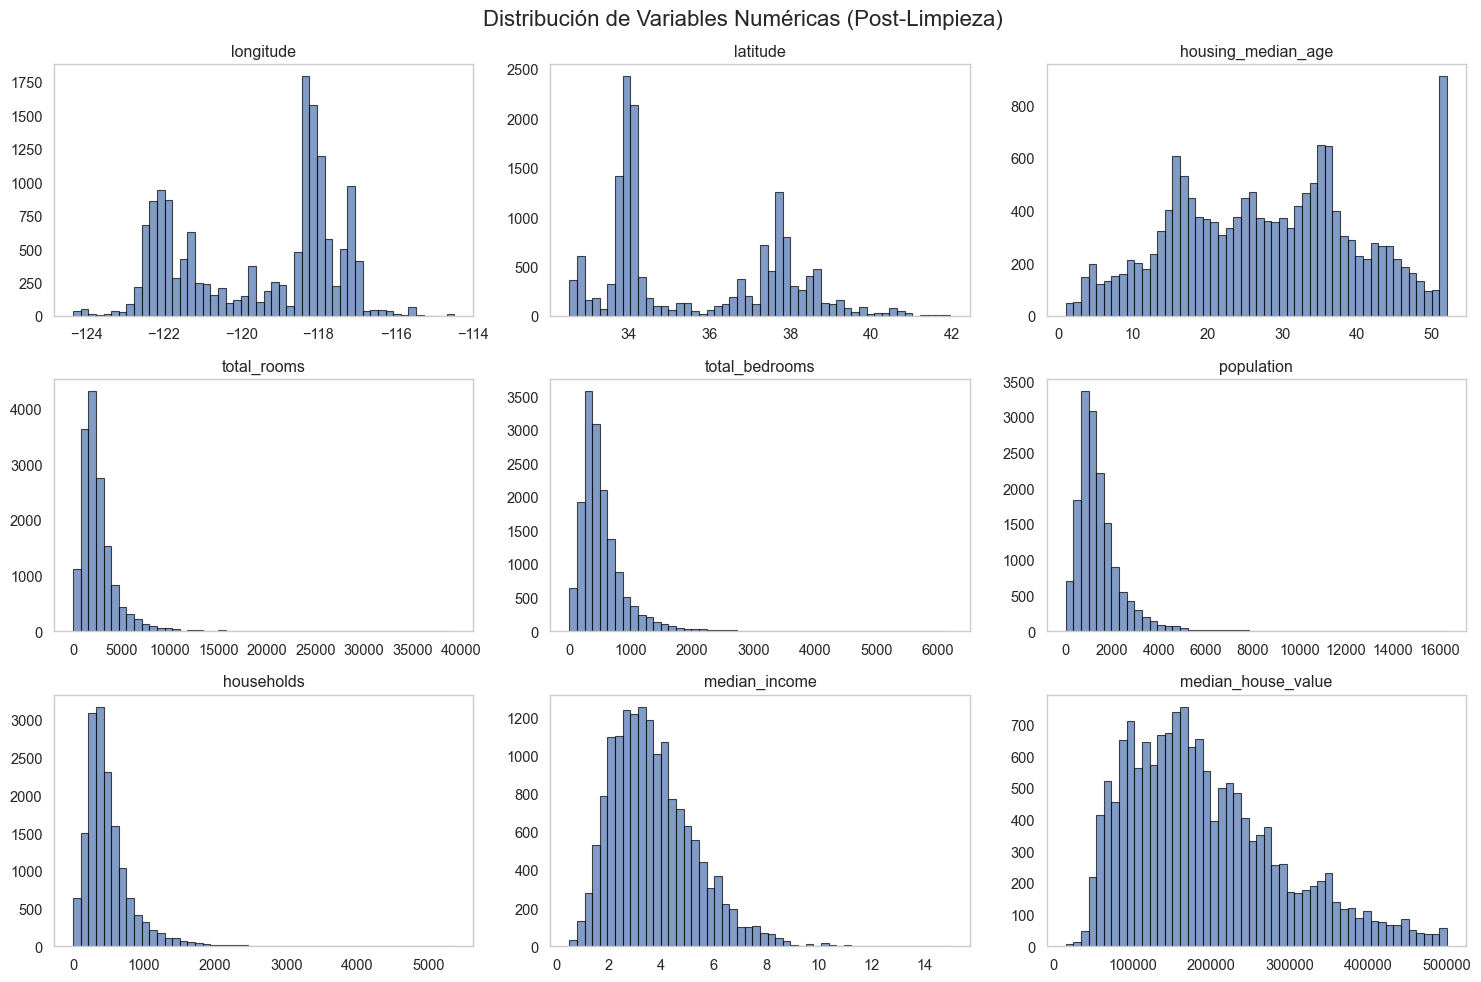

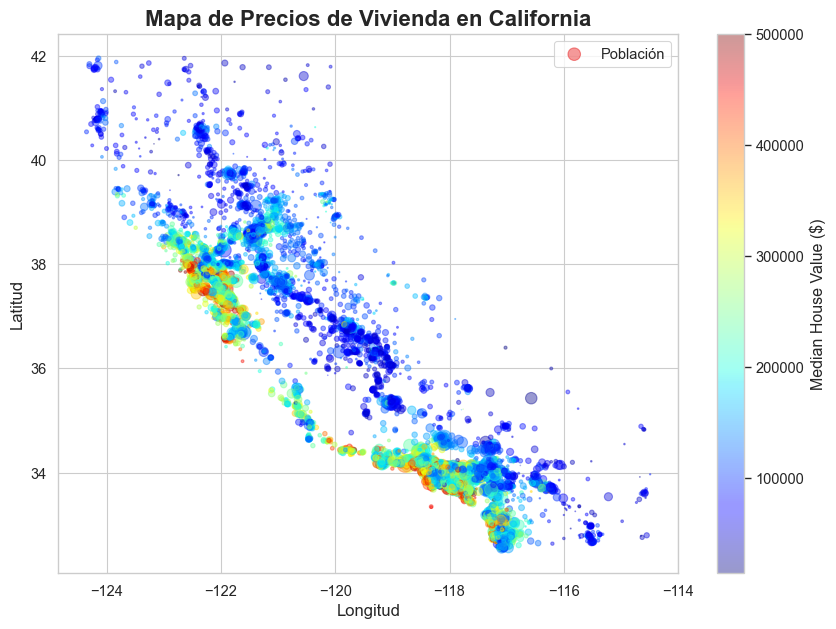

In [2]:

# LIMPIEZA DE DATOS (DATA CLEANING)

print(f"Tamaño original: {df_eda.shape}")

# 1. Eliminar inconsistencias lógicas (10 filas)
filtro_logico = (df_eda['population'] >= df_eda['households']) & (df_eda['population'] / df_eda['households'] <= 20)
df_clean = df_eda[filtro_logico].copy()

# 2. Eliminar censura de la variable objetivo (764 filas)
df_clean = df_clean[df_clean['median_house_value'] < 500001].copy()

print(f"Tamaño tras limpieza: {df_clean.shape}")
print(f"Registros eliminados: {df_eda.shape[0] - df_clean.shape[0]}")

# 3. VISUALIZACIÓN DE DISTRIBUCIONES (HISTOGRAMAS)
# Desactivamos el límite de subplots para verlos todos juntos
df_clean.hist(bins=50, figsize=(15, 10), grid=False, edgecolor='black', alpha=0.7)
plt.suptitle("Distribución de Variables Numéricas (Post-Limpieza)", fontsize=16)
plt.tight_layout()
plt.show()

# 4. VISUALIZACIÓN GEOESPACIAL (EL MAPA DE CALIFORNIA)
plt.figure(figsize=(10, 7))

# scatter plot según tus instrucciones
scatter = plt.scatter(
    x=df_clean['longitude'], 
    y=df_clean['latitude'], 
    alpha=0.4, # Transparencia para ver densidad
    s=df_clean['population']/100, # El tamaño del punto = Población
    c=df_clean['median_house_value'], # El color = Precio de la casa
    cmap=plt.get_cmap('jet'), # Mapa de calor (Azul=Barato, Rojo=Caro)
    label='Población'
)

plt.colorbar(scatter, label='Median House Value ($)')
plt.xlabel("Longitud", fontsize=12)
plt.ylabel("Latitud", fontsize=12)
plt.title("Mapa de Precios de Vivienda en California", fontsize=16, fontweight='bold')
plt.legend()
plt.show()

## 2. Análisis de calidad
#### 2.1. Análisis de Precisión

In [3]:
# AUDITORÍA DE PRECISIÓN Y DUPLICADOS (TRICKYS)

print("--- 1. ANÁLISIS DE DUPLICADOS ---")
# Duplicados explícitos (filas idénticas en todas las columnas)
dup_exactos = df_eda.duplicated().sum()
print(f"Duplicados exactos: {dup_exactos}")

# Duplicados implícitos espaciales (Mismas coordenadas, distintos datos)
# En un censo, es muy raro que dos 'block groups' tengan EXACTAMENTE el mismo centroide (lat/lon)
dup_espaciales = df_eda.duplicated(subset=['longitude', 'latitude'], keep=False)
num_dup_espaciales = dup_espaciales.sum()
print(f"Filas con coordenadas duplicadas (Posible error de recolección): {num_dup_espaciales} ({(num_dup_espaciales/len(df_eda))*100:.2f}%)")

if num_dup_espaciales > 0:
    # Mostramos un par de ejemplos para entender qué está pasando
    display(df_eda[dup_espaciales].sort_values(by=['longitude', 'latitude']).head(4))


print("\n--- 2. INCONSISTENCIAS LÓGICAS (TRICKYS) ---")
inconsistencias = {}

# A. Lógica Física: No puedes tener más cuartos de baño/dormitorios que cuartos totales
error_cuartos = df_eda[df_eda['total_bedrooms'] > df_eda['total_rooms']]
inconsistencias['Dormitorios > Cuartos totales'] = len(error_cuartos)

# B. Lógica Demográfica: Personas por hogar
# households representa las unidades de vivienda OCUPADAS.
# Si population < households, implica vecindarios con menos de 1 persona por casa (casas fantasma o error)
error_demografico = df_eda[df_eda['population'] < df_eda['households']]
inconsistencias['Población < Hogares (Casas fantasma)'] = len(error_demografico)

# Extra: Sobrepoblación extrema (outliers severos de densidad)
# Calculamos habitantes por hogar y buscamos cosas ridículas (ej. > 20 personas por casa en promedio)
df_eda['personas_por_hogar'] = df_eda['population'] / df_eda['households']
error_hacinamiento = df_eda[df_eda['personas_por_hogar'] > 20]
inconsistencias['Hacinamiento extremo (>20 pers/hogar)'] = len(error_hacinamiento)

for falla, cantidad in inconsistencias.items():
    print(f"{falla}: {cantidad} registros detectados")


print("\n--- 3. CENSURA DE DATOS (VALORES TOPADOS) ---")
# En las encuestas gubernamentales, a menudo se 'topan' los valores máximos por privacidad o diseño de la encuesta.
# Vamos a contar cuántos registros están pegados al límite máximo de las variables clave.

max_age = df_eda['housing_median_age'].max()
max_val = df_eda['median_house_value'].max()

top_age_count = (df_eda['housing_median_age'] == max_age).sum()
top_val_count = (df_eda['median_house_value'] == max_val).sum()

print(f"Casas topadas en edad máxima ({max_age} años): {top_age_count} registros ({(top_age_count/len(df_eda))*100:.2f}%)")
print(f"Casas topadas en valor máximo (${max_val}): {top_val_count} registros ({(top_val_count/len(df_eda))*100:.2f}%)")

--- 1. ANÁLISIS DE DUPLICADOS ---
Duplicados exactos: 0
Filas con coordenadas duplicadas (Posible error de recolección): 8966 (54.30%)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4008,-124.180,40.780,37.000,1453.000,293.000,867.000,310.000,2.554,70200.000,NEAR OCEAN
8862,-124.180,40.780,34.000,1592.000,364.000,950.000,317.000,2.161,67000.000,NEAR OCEAN
8932,-124.180,40.790,40.000,1398.000,311.000,788.000,279.000,1.467,64600.000,NEAR OCEAN
10032,-124.180,40.790,39.000,1836.000,352.000,883.000,337.000,1.745,70500.000,NEAR OCEAN



--- 2. INCONSISTENCIAS LÓGICAS (TRICKYS) ---
Dormitorios > Cuartos totales: 0 registros detectados
Población < Hogares (Casas fantasma): 3 registros detectados
Hacinamiento extremo (>20 pers/hogar): 7 registros detectados

--- 3. CENSURA DE DATOS (VALORES TOPADOS) ---
Casas topadas en edad máxima (52.0 años): 1004 registros (6.08%)
Casas topadas en valor máximo ($500001.0): 764 registros (4.63%)


Más de la mitad del set de prueba tiene duplicados por coordinadas exactas. Buscando en internet en los datos del censo de EE. UU., las coordenadas (latitud y longitud) a menudo se redondean o se asignan al "centroide" de una cuadrícula muy grande. Es decir, tienes múltiples block groups (vecindarios) que el sistema agrupó en el mismo punto exacto del mapa. Por este motivo NO se eliminarán

Se identificaron también 3 registros fantasmas con más casas que personas, y 7 registros con más de 20 personas por cada casa. Dado que son 10 casos marginales de un dataset de más de 16,000, se eliminarán este tipo de registros 

Sobre la edad máxima un 6% de registros tienen exactamente 52 años, y casi un 5% de datos tienen un valor de 500,001. Para el primer caso no se eliminarán los valores pues 52 puede redefinirse como el tope máximo. Sin embargo para el caso del precio máximo, se eliminarán estos registros pues es nuestra variable predecida, y dejar ese valor máximo sesgará el análisis y nunca predeciré casas de más de ese valor. 

#### 2.2. Análisis de Completitud

--- 1. VISUALIZACIÓN MACRO DE NULOS ---


<Figure size 1000x400 with 0 Axes>

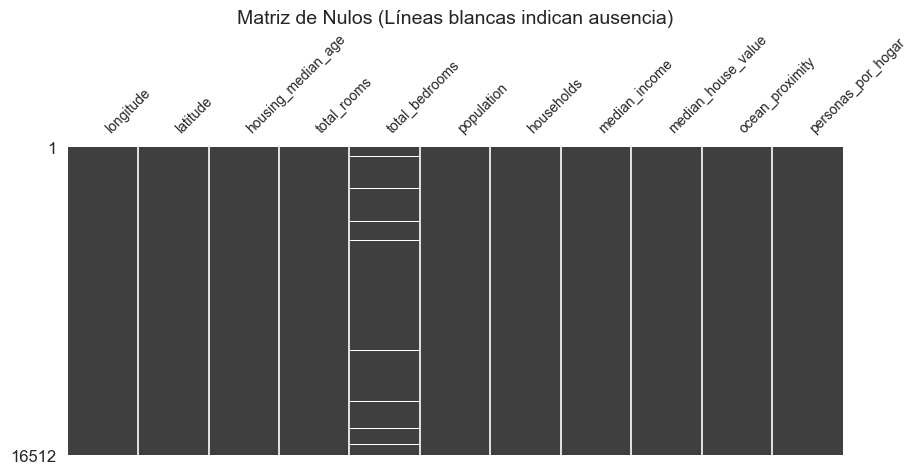


--- 2. CREACIÓN DE SHADOW VARIABLE Y TEST ESTADÍSTICO ---
Registros SIN nulos: 16344
Registros CON nulos: 168


,Variable,KS-Statistic,p-value,Interpretación (alpha=0.05)
0,median_income,0.090,0.124,Distribuciones Iguales (Consistente con MCAR)
1,median_house_value,0.058,0.614,Distribuciones Iguales (Consistente con MCAR)
2,households,0.080,0.221,Distribuciones Iguales (Consistente con MCAR)
3,population,0.068,0.409,Distribuciones Iguales (Consistente con MCAR)



--- 3. VISUALIZACIÓN BIVARIADA DE LA AUSENCIA (KDE PLOTS) ---


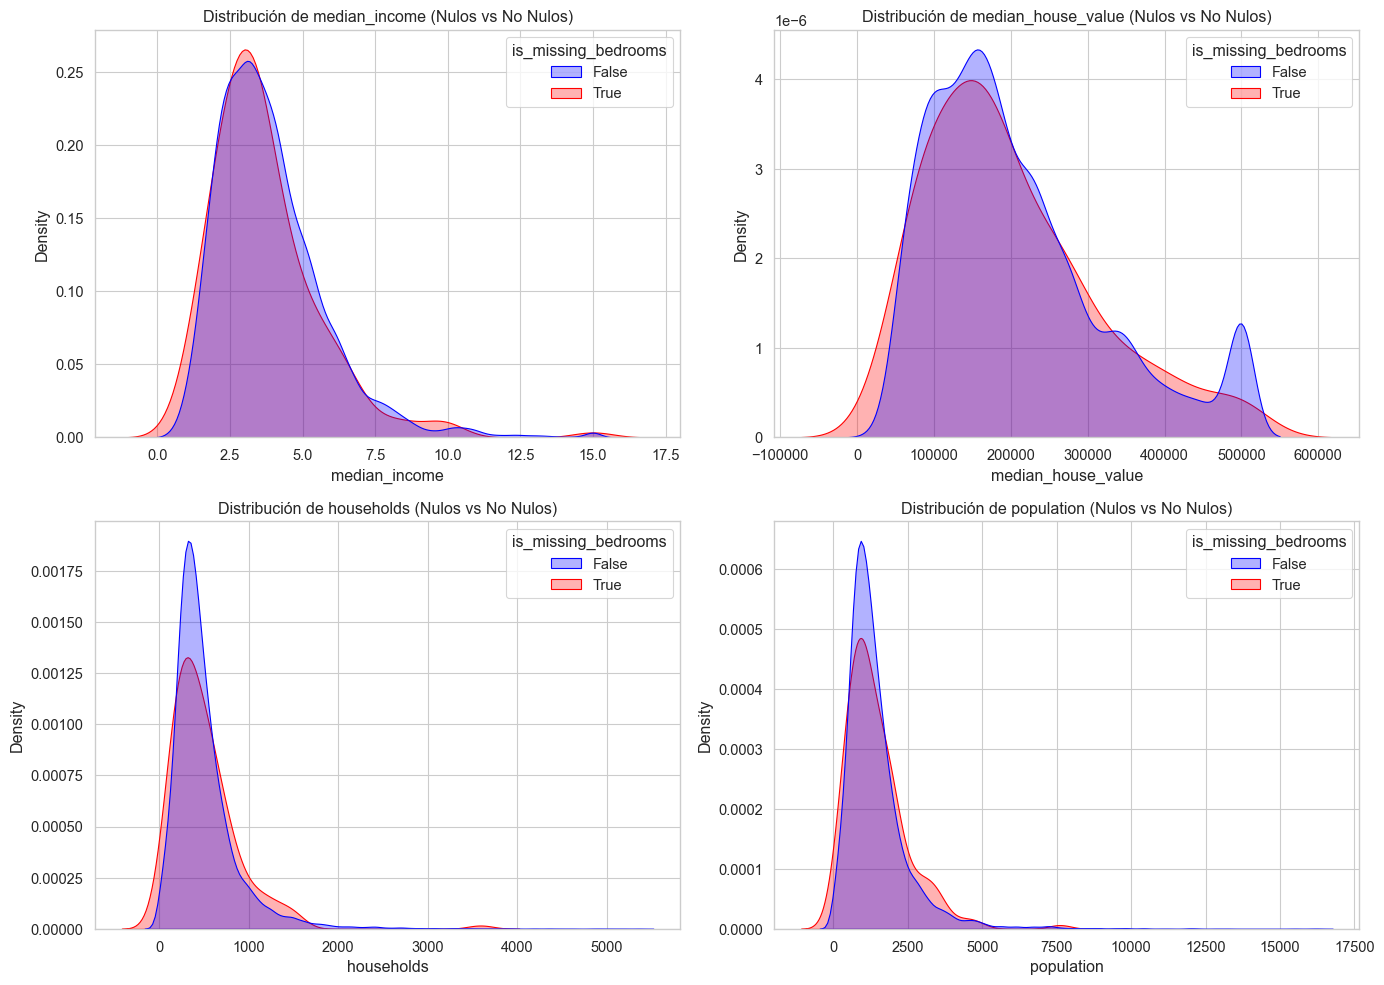

In [4]:
# ANÁLISIS DE MECANISMOS DE AUSENCIA (MISSINGNESS)
print("--- 1. VISUALIZACIÓN MACRO DE NULOS ---")
# msno.matrix nos da una visión topológica de dónde caen los nulos.
# Si hubieran nulos en varias columnas, veríamos si ocurren en las mismas filas.
plt.figure(figsize=(10, 4))
msno.matrix(df_eda, sparkline=False, figsize=(10,4), fontsize=10)
plt.title("Matriz de Nulos (Líneas blancas indican ausencia)", fontsize=14)
plt.show()

print("\n--- 2. CREACIÓN DE SHADOW VARIABLE Y TEST ESTADÍSTICO ---")
# Creamos una variable booleana que indica si falta el dormitorio
df_eda['is_missing_bedrooms'] = df_eda['total_bedrooms'].isnull()

# Separamos las poblaciones
con_nulos = df_eda[df_eda['is_missing_bedrooms'] == True]
sin_nulos = df_eda[df_eda['is_missing_bedrooms'] == False]

print(f"Registros SIN nulos: {len(sin_nulos)}")
print(f"Registros CON nulos: {len(con_nulos)}")

# Vamos a evaluar si la ausencia de 'total_bedrooms' está sesgada por otras variables clave.
# Hipótesis Nula (H0): Las distribuciones son iguales (indica MCAR).
# Hipótesis Alternativa (H1): Las distribuciones son distintas (indica MAR).

variables_diagnostico = ['median_income', 'median_house_value', 'households', 'population']
resultados_test = []

for var in variables_diagnostico:
    # Usamos el Test de Kolmogorov-Smirnov para comparar dos distribuciones independientes
    stat, p_value = stats.ks_2samp(con_nulos[var], sin_nulos[var])
    
    resultados_test.append({
        'Variable': var,
        'KS-Statistic': stat,
        'p-value': p_value,
        'Interpretación (alpha=0.05)': 'Distribuciones Distintas (Posible MAR)' if p_value < 0.05 else 'Distribuciones Iguales (Consistente con MCAR)'
    })

# Mostrar resultados formales
df_missing_stats = pd.DataFrame(resultados_test)
display(df_missing_stats)

print("\n--- 3. VISUALIZACIÓN BIVARIADA DE LA AUSENCIA (KDE PLOTS) ---")
# Graficamos para validar visualmente el test estadístico
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables_diagnostico):
    sns.kdeplot(data=df_eda, x=var, hue='is_missing_bedrooms', common_norm=False, 
                fill=True, alpha=0.3, ax=axes[i], palette={True: 'red', False: 'blue'})
    axes[i].set_title(f'Distribución de {var} (Nulos vs No Nulos)')

plt.tight_layout()
plt.show()

# Limpieza: Borramos la variable shadow para no contaminar la matriz de correlación del paso 5
df_eda.drop(columns=['is_missing_bedrooms'], inplace=True)

--- 1. IMPUTACIÓN DE TOTAL_BEDROOMS ---
Nulos restantes en el dataset: 0

--- 2. MATRIZ DE CORRELACIÓN (PEARSON) ---
Correlación con median_house_value:


,median_house_value
median_house_value,1.000
median_income,0.688
total_rooms,0.137
housing_median_age,0.102
households,0.071
total_bedrooms,0.056
population,-0.020
personas_por_hogar,-0.038
longitude,-0.051
latitude,-0.140


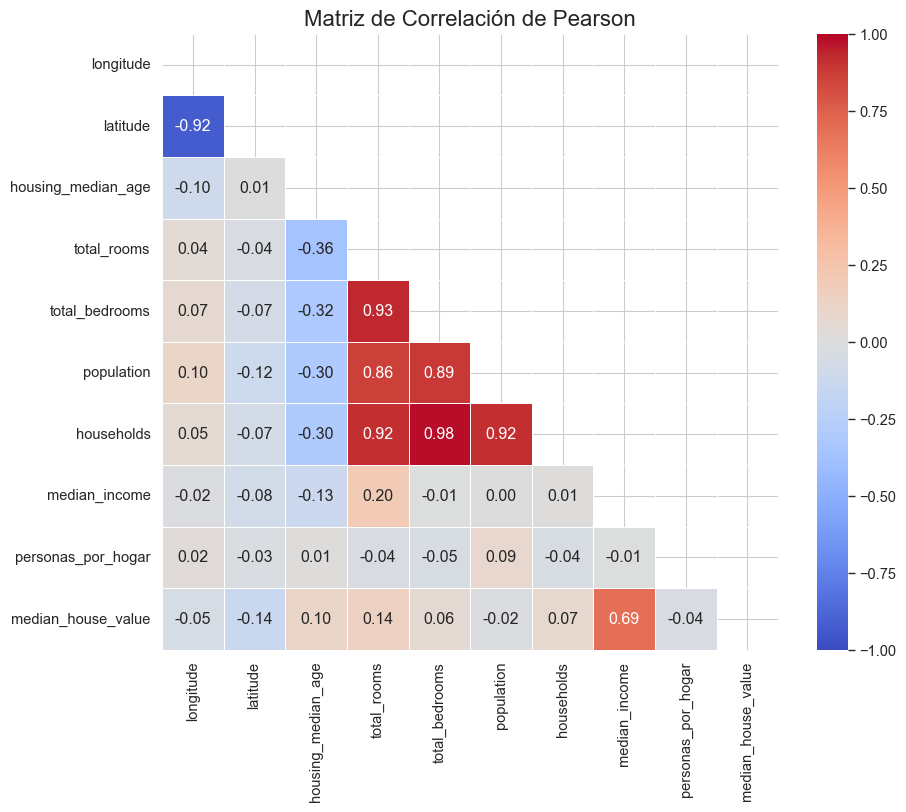


--- 3. RELACIONES NO LINEALES Y DISPERSIÓN ---


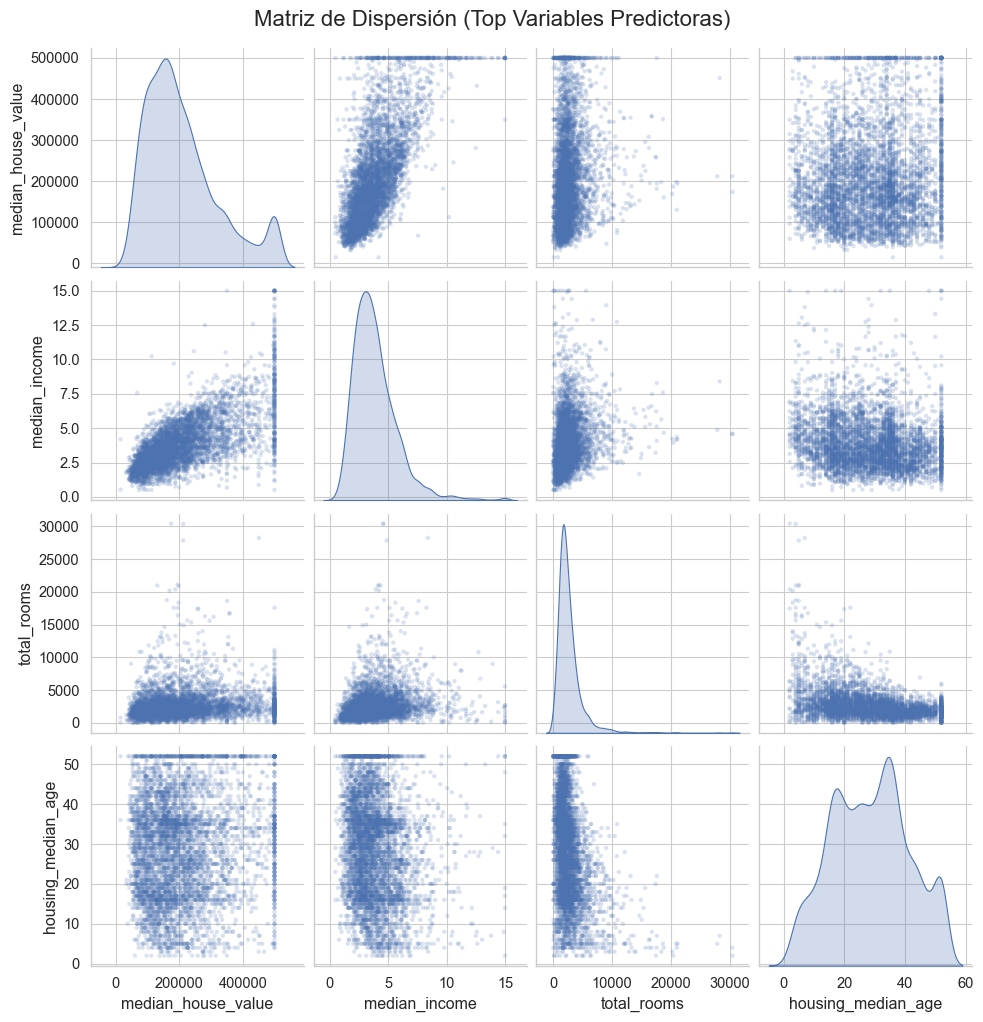

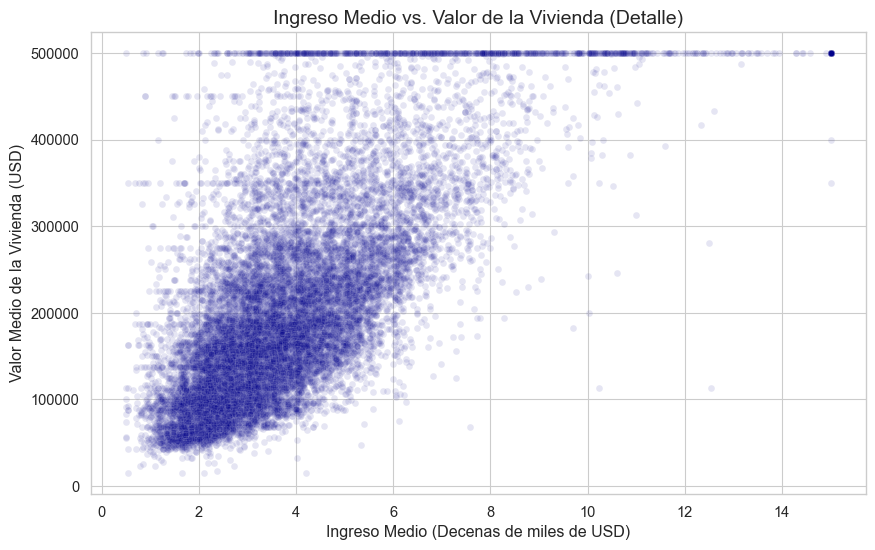

In [5]:
# 8. IMPUTACIÓN DE NULOS (MCAR)
print("--- 1. IMPUTACIÓN DE TOTAL_BEDROOMS ---")

df_imputed = df_eda.copy()
    
# Separar categóricas y target (NUNCA imputar usando el target en la industria para evitar leakage)
target = df_imputed['median_house_value']
categoricas = df_imputed[['ocean_proximity']]
    
# Variables a usar para encontrar a los vecinos
features_knn = df_imputed.drop(columns=['median_house_value', 'ocean_proximity'])
column_names = features_knn.columns
    
# Aplicar KNN Imputer
# Supuesto: Vecindarios con métricas similares (cuartos, población, lat/lon) 
# tendrán un número similar de dormitorios.
imputer = KNNImputer(n_neighbors=5, weights='distance')
features_imputed = imputer.fit_transform(features_knn)
    
# Reconstruir el DataFrame
df_features = pd.DataFrame(features_imputed, columns=column_names, index=df_imputed.index)
    
# Unir todo de nuevo
df_final = pd.concat([df_features, categoricas, target], axis=1)

df_eda = df_final.copy()

# Verificamos que ya no haya nulos
print(f"Nulos restantes en el dataset: {df_eda.isnull().sum().sum()}")

# 9. MATRIZ DE CORRELACIÓN Y MULTICOLINEALIDAD
print("\n--- 2. MATRIZ DE CORRELACIÓN (PEARSON) ---")
# Calculamos la correlación lineal de Pearson (solo para variables numéricas)
corr_matrix = df_eda.corr(numeric_only=True)

# Nos enfocamos en cómo cada variable se correlaciona con nuestro Target
corr_target = corr_matrix['median_house_value'].sort_values(ascending=False)
print("Correlación con median_house_value:")
display(corr_target.to_frame())

# Visualización profesional: Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
# Usamos una máscara para tapar la mitad superior del mapa (es redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, square=True, linewidths=.5)
plt.title("Matriz de Correlación de Pearson", fontsize=16)
plt.show()

# 10. GRÁFICOS DE DISPERSIÓN (SCATTER PLOTS)
print("\n--- 3. RELACIONES NO LINEALES Y DISPERSIÓN ---")
# Escogemos las 3 variables más prometedoras según la correlación para graficarlas
variables_top = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']

# Usamos un sample de los datos para que el gráfico no tarde una eternidad en renderizar
sns.pairplot(df_eda[variables_top].sample(min(5000, len(df_eda)), random_state=42), 
             diag_kind='kde', 
             plot_kws={'alpha': 0.2, 's': 10, 'edgecolor': 'none'})
plt.suptitle("Matriz de Dispersión (Top Variables Predictoras)", y=1.02, fontsize=16)
plt.show()

# Zoom específico a la relación más fuerte (Ingreso vs Precio)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='median_income', y='median_house_value', alpha=0.1, color='darkblue')
plt.title("Ingreso Medio vs. Valor de la Vivienda (Detalle)", fontsize=14)
plt.xlabel("Ingreso Medio (Decenas de miles de USD)")
plt.ylabel("Valor Medio de la Vivienda (USD)")
plt.show()

El análisis de la variable total_bedrooms y su shadow matrix confirma MCAR.Evidencia: El test de Kolmogorov-Smirnov arrojó p-valores significativamente superiores al umbral de $0.05$ en todas las variables diagnósticas (Ingreso, Valor de Vivienda, Población).Impacto: Esto garantiza que la ausencia de datos no está sesgada por el nivel socioeconómico o la ubicación Decisión: Si la imputación por mediana seriía una estrategia robusta y segura, se utilizará KNN para mantener la relación multivariada y reducir el ruido del error residual.

La variable median_income es el mayor predictor del valor de la vivienda ($r = 0.69$). El gráfico de dispersión muestra una relación lineal clara y positiva. Sin embargo, se observa una línea horizontal persistente en los $500,000. 

Nota de Precaución: A pesar de la limpieza, si la frontera de censura permanece en el dataset, el modelo desarrollará un "techo artificial" en sus predicciones. Es vital documentar que la precisión del modelo podría degradarse significativamente para propiedades que superen este umbral de lujo, ya que el dataset original está "truncado".

La Matriz de Correlación de Pearson revela presencia de multicolinealidad, las variables total_rooms, total_bedrooms, population y households presentan correlaciones entre sí superiores a $0.85$. Incluir todas estas variables en una regresión inflará la varianza de los coeficientes, haciendo que el modelo sea inestable. Decisión: transformar estas métricas de "conteo absoluto" en ratios de intensidad (ej. habitaciones por hogar, dormitorios por habitación)



#### 2.3. Análisis de Sensibilidad

--- 1. DIAGNÓSTICO ESTADÍSTICO: MÉTODO IQR ---


,Variable,Límite Inf,Límite Sup,Total Outliers,% Outliers,Max Valor Real
3,total_bedrooms,-231.500,1172.500,1048,6.350,6210.000
2,total_rooms,-1113.500,5714.500,1041,6.300,39320.000
4,households,-207.000,1089.000,995,6.030,5358.000
1,population,-621.500,3134.500,969,5.870,16305.000
0,median_income,-0.720,8.030,537,3.250,15.000



--- 2. INSPECCIÓN VISUAL DE COLAS PESADAS ---


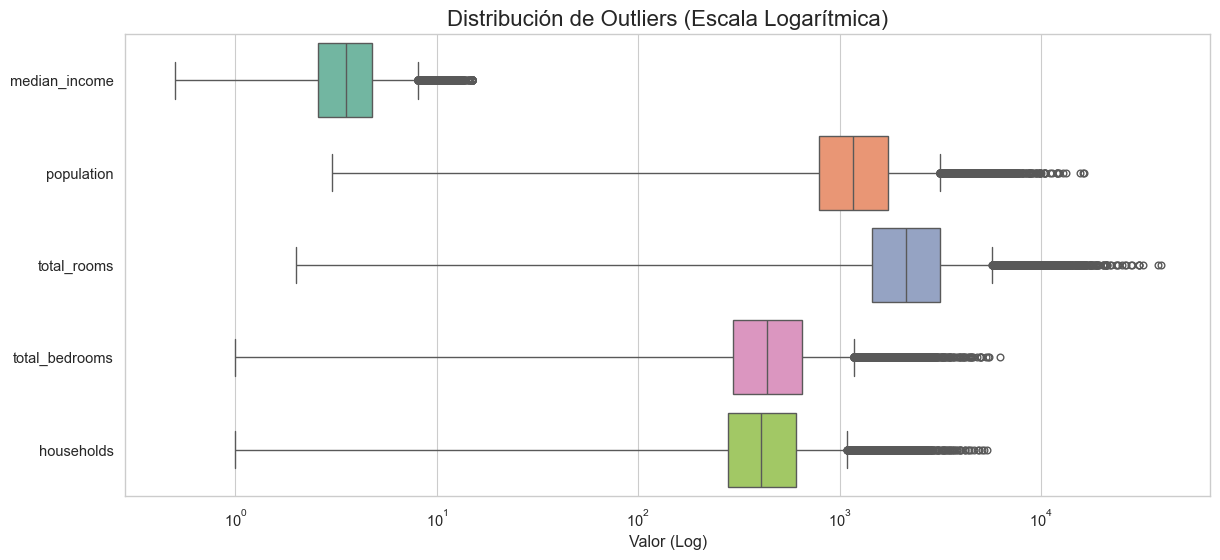


--- 3. EJEMPLO DE TRATAMIENTO: LOG-TRANSFORM EN POBLACIÓN ---


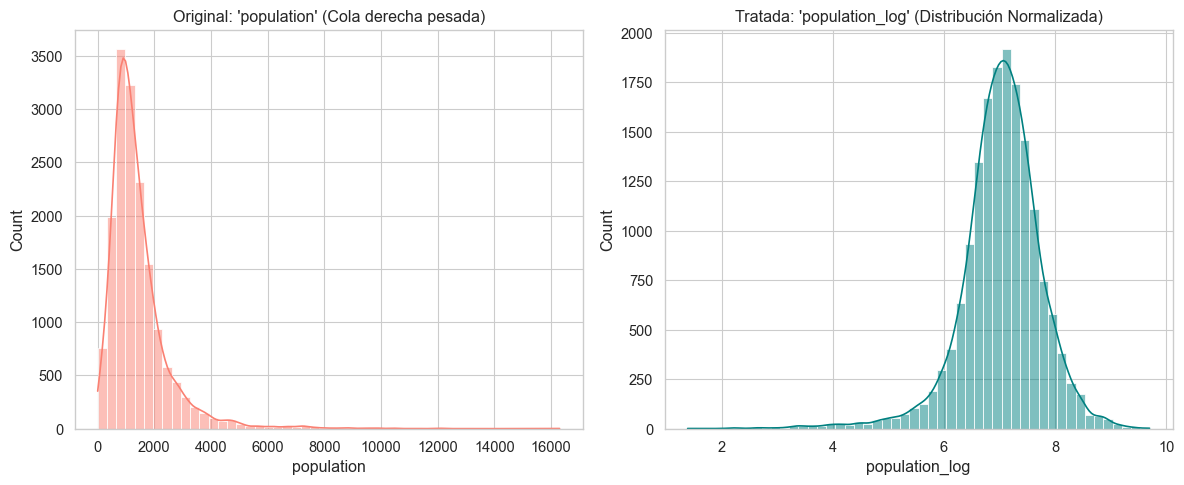

In [6]:
# 11. ANÁLISIS DE SENSIBILIDAD Y OUTLIERS (UNIVARIADO)
print("--- 1. DIAGNÓSTICO ESTADÍSTICO: MÉTODO IQR ---")

def diagnostico_outliers_iqr(df, columnas):
    """
    Calcula la cantidad y porcentaje de outliers usando el Rango Intercuartílico (IQR).
    Límites: Q1 - 1.5*IQR y Q3 + 1.5*IQR.
    """
    resultados = []
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)]
        porcentaje = (len(outliers) / len(df)) * 100
        
        resultados.append({
            'Variable': col,
            'Límite Inf': round(limite_inf, 2),
            'Límite Sup': round(limite_sup, 2),
            'Total Outliers': len(outliers),
            '% Outliers': round(porcentaje, 2),
            'Max Valor Real': round(df[col].max(), 2)
        })
    return pd.DataFrame(resultados).sort_values(by='% Outliers', ascending=False)

# Evaluamos las variables numéricas continuas principales
vars_numericas = ['median_income', 'population', 'total_rooms', 'total_bedrooms', 'households']
df_outliers = diagnostico_outliers_iqr(df_eda, vars_numericas)
display(df_outliers)

# 12. VISUALIZACIÓN DE LA SENSIBILIDAD (BOXPLOTS)
print("\n--- 2. INSPECCIÓN VISUAL DE COLAS PESADAS ---")
plt.figure(figsize=(14, 6))

# Boxplot múltiple (Estandarizamos visualmente con escala Logarítmica para poder compararlos)
sns.boxplot(data=df_eda[vars_numericas], orient='h', palette='Set2')
plt.xscale('log') # Escala logarítmica solo para visualización porque las escalas son muy distintas
plt.title("Distribución de Outliers (Escala Logarítmica)", fontsize=16)
plt.xlabel("Valor (Log)")
plt.show()

# 13. TRATAMIENTO PROPUESTO: TRANSFORMACIÓN VS CLIPPING
print("\n--- 3. EJEMPLO DE TRATAMIENTO: LOG-TRANSFORM EN POBLACIÓN ---")
# La población tiene outliers masivos (vecindarios de 35,000 personas).
# Borrarlos pierde datos valiosos. Cortarlos (Clipping) altera la realidad.
# La solución analítica top es Transformar la varianza usando Logaritmo Natural.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes del tratamiento
sns.histplot(df_eda['population'], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title("Original: 'population' (Cola derecha pesada)")

# Aplicamos Log1p (Logaritmo natural de 1 + x, para evitar log(0))
df_eda['population_log'] = np.log1p(df_eda['population'])

# Después del tratamiento
sns.histplot(df_eda['population_log'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title("Tratada: 'population_log' (Distribución Normalizada)")

plt.tight_layout()
plt.show()

# Limpieza: Borramos la variable de prueba
df_eda.drop(columns=['population_log'], inplace=True)

Los valores máximos (ej. 39,320 cuartos frente a un límite sugerido de 5,714) no son errores de digitación. Reflejan la heterogeneidad urbana. California tiene desde zonas rurales dispersas hasta bloques censales con complejos de apartamentos masivos. Estamos ante distribuciones de "cola pesada" (heavy-tailed). El método IQR asume una distribución normal (donde solo el 0.7% serían outliers); al tener >6%, confirmamos que estas variables siguen una distribución Log-Normal.

El ingreso está "suavizado". Aunque el límite estadístico es 8.0, un ingreso de 15 ($150k) es una realidad socioeconómica común en zonas como Palo Alto o Beverly Hills. A diferencia de las variables de volumen, el ingreso tiene una correlación de 0.69 con el precio. Tratar estos outliers agresivamente sería eliminar la señal más fuerte que tiene el modelo para predecir casas caras.

Pese a esto, no se eliminaran ninguno de los 1,068 registros detectados como outliers en estas variables. En un problema de regresión de este tipo, los vecindarios atípicos (muy densos o muy ricos) son los que definen los límites del mercado. Si los borramos, el modelo será incapaz de generalizar en zonas urbanas densas o zonas de alto poder adquisitivo

Se creará rooms_per_household y bedrooms_per_room. Estas nuevas variables deberían tener distribuciones mucho más cercanas a la normal y una sensibilidad a outliers menor.

Aplicar np.log1p() a population, total_rooms y total_bedrooms, esto pues el valor máximo es hasta 6 veces el límite superior del IQR, una escala lineal "aplastará" al resto de los datos en modelos de gradiente. El logaritmo natural reducirá la magnitud de los outliers sin perder orden jerárquico.

#### 2.4. Análisis de Consistencia

In [7]:
# 14. ANÁLISIS DE CONSISTENCIA (DOMAIN KNOWLEDGE)
print("--- 1. CONSISTENCIA CATEGÓRICA Y DESBALANCE EXTREMO ---")
# En las correlaciones anteriores ignoramos 'ocean_proximity' por ser texto.
# Aquí evaluamos su integridad.

if 'ocean_proximity' in df_eda.columns:
    cat_counts = df_eda['ocean_proximity'].value_counts()
    cat_pct = df_eda['ocean_proximity'].value_counts(normalize=True) * 100
    
    df_categorias = pd.DataFrame({
        'Conteo': cat_counts,
        'Porcentaje (%)': cat_pct.round(3)
    })
    display(df_categorias)
    
    # Buscamos clases minoritarias extremas (< 0.1%)
    clases_criticas = df_categorias[df_categorias['Porcentaje (%)'] < 0.1]
    if not clases_criticas.empty:
        print(f"\n¡ALERTA!: Se detectaron categorías con representación crítica:")
        display(clases_criticas)
else:
    print("Nota: Asegúrate de no haber borrado 'ocean_proximity' en pasos previos.")


print("\n--- 2. CONSISTENCIA GEOESPACIAL (BOUNDING BOX) ---")
# California tiene límites geográficos físicos bien definidos.
# Latitud: ~32.5 (Frontera con México) a ~42.0 (Frontera con Oregón)
# Longitud: ~-124.3 (Costa) a ~-114.1 (Frontera con Nevada/Arizona)

fuera_lat = df_eda[(df_eda['latitude'] < 32.5) | (df_eda['latitude'] > 42.0)]
fuera_lon = df_eda[(df_eda['longitude'] < -124.3) | (df_eda['longitude'] > -114.1)]

errores_geoespaciales = len(fuera_lat) + len(fuera_lon)
print(f"Registros fuera de los límites lógicos de latitud: {len(fuera_lat)}")
print(f"Registros fuera de los límites lógicos de longitud: {len(fuera_lon)}")

if errores_geoespaciales == 0:
    print("-> ÉXITO: Todos los registros son geoespacialmente consistentes con California.")
else:
    print("-> ADVERTENCIA: Se detectaron coordenadas imposibles. Deben ser eliminadas.")

--- 1. CONSISTENCIA CATEGÓRICA Y DESBALANCE EXTREMO ---


,Conteo,Porcentaje (%)
ocean_proximity,,
<1H OCEAN,7274,44.053
INLAND,5301,32.104
NEAR OCEAN,2089,12.651
NEAR BAY,1846,11.180
ISLAND,2,0.012



¡ALERTA!: Se detectaron categorías con representación crítica:


,Conteo,Porcentaje (%)
ocean_proximity,,
ISLAND,2,0.012



--- 2. CONSISTENCIA GEOESPACIAL (BOUNDING BOX) ---
Registros fuera de los límites lógicos de latitud: 0
Registros fuera de los límites lógicos de longitud: 1
-> ADVERTENCIA: Se detectaron coordenadas imposibles. Deben ser eliminadas.
